# Factor Model and Time Series Analysis: Tesla (TSLA) vs Disney (DIS)

**Period:** January 3, 2011 – December 31, 2025 (daily data)  
**Models:** Capital Asset Pricing Model (CAPM) and Fama-French 3-Factor Model (FF3)

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
import statsmodels.api as sm
import scipy.stats

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import probplot

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1. Data Assembly

The analysis requires two data sources merged on a common daily date index:

- **Price data** for TSLA and DIS from Yahoo Finance, converted to simple daily returns via percentage change.
- **Fama-French factor data** from the local CSV, which provides the market excess return (Mkt-RF), size premium (SMB), value premium (HML), and the risk-free rate (RF).

The FF file stores factor values in *percent* units (e.g., a value of `0.50` means 0.50%). Because `pct_change()` produces decimal returns (e.g., `0.005` for 0.5%), all four FF columns must be divided by 100 before merging so the units are consistent across the regression.

In [25]:
# --- Price data ---
# end='2026-01-01' ensures December 31, 2025 is included (yfinance end date is exclusive)
raw = yf.download(
    ['TSLA', 'DIS'],
    start='2011-01-03',
    end='2026-01-01',
    auto_adjust=True,
    progress=False
)
prices = raw['Close'][['TSLA', 'DIS']]
prices.index = pd.to_datetime(prices.index)

print('Price data shape:', prices.shape)
print('Price date range:', prices.index.min(), 'to', prices.index.max())
prices.head()

Price data shape: (3772, 2)
Price date range: 2011-01-03 00:00:00 to 2025-12-31 00:00:00


Ticker,TSLA,DIS
Date,,
2011-01-03,1.774667,32.536442
2011-01-04,1.778000,33.542992
2011-01-05,1.788667,34.377483
2011-01-06,1.858667,34.110794
2011-01-07,1.882667,33.938725


In [26]:
# --- Fama-French factor data ---
ff_raw = pd.read_csv(
    'fda1_stock_factor_data.csv',
    index_col='Date',
    parse_dates=True
)

# Keep only the four FF columns we need; discard ticker columns and extra factors
ff = ff_raw[['Mkt-RF', 'SMB', 'HML', 'RF']].copy()

# Convert from percent to decimal to match pct_change() return units
ff = ff / 100

print('FF factor data — first rows (values should be ~0.001 scale, not ~0.1):')
print(ff.head())
print()
print('FF factor data — descriptive statistics:')
ff.describe()

FF factor data — first rows (values should be ~0.001 scale, not ~0.1):
            Mkt-RF     SMB     HML      RF
Date                                      
2006-01-03  0.0150 -0.0012  0.0016  0.0002
2006-01-04  0.0046  0.0031  0.0002  0.0002
2006-01-05  0.0003  0.0025 -0.0010  0.0002
2006-01-06  0.0093  0.0009 -0.0025  0.0002
2006-01-09  0.0045  0.0052 -0.0018  0.0002

FF factor data — descriptive statistics:


,Mkt-RF,SMB,HML,RF
count,5031.000000,5031.000000,5031.000000,5031.000000
mean,0.000431,-0.000022,-0.000040,0.000067
std,0.012433,0.006479,0.008152,0.000084
min,-0.120100,-0.045800,-0.050300,0.000000
25%,-0.004250,-0.003700,-0.003600,0.000000
50%,0.000800,-0.000100,-0.000300,0.000000
75%,0.006050,0.003500,0.003300,0.000100
max,0.113600,0.057100,0.067300,0.000200


In [27]:
# --- Daily simple returns ---
# pct_change() computes (P_t - P_{t-1}) / P_{t-1}; drop the first row which is NaN
returns = prices.pct_change().dropna()
returns.index = pd.to_datetime(returns.index)

print('Returns shape:', returns.shape)
returns.head()

Returns shape: (3771, 2)


Ticker,TSLA,DIS
Date,,
2011-01-04,0.001878,0.030936
2011-01-05,0.005999,0.024878
2011-01-06,0.039135,-0.007758
2011-01-07,0.012912,-0.005044
2011-01-10,0.007436,0.001268


In [28]:
# --- Merge returns with FF factors ---
# Inner join keeps only dates present in both sources, ensuring no misaligned observations.
# dropna() removes any residual missing values from either source.
data = returns.join(ff, how='inner').dropna()

print('Merged dataset shape:', data.shape)
print('Date range:', data.index.min(), 'to', data.index.max())
print()
data.head()

Merged dataset shape: (3771, 6)
Date range: 2011-01-04 00:00:00 to 2025-12-31 00:00:00



,TSLA,DIS,Mkt-RF,SMB,HML,RF
Date,,,,,,
2011-01-04,0.001878,0.030936,-0.0026,-0.0130,-0.0002,0.0
2011-01-05,0.005999,0.024878,0.0060,0.0062,0.0012,0.0
2011-01-06,0.039135,-0.007758,-0.0015,-0.0012,-0.0033,0.0
2011-01-07,0.012912,-0.005044,-0.0021,-0.0026,-0.0021,0.0
2011-01-10,0.007436,0.001268,-0.0002,0.0047,-0.0014,0.0


The merged DataFrame `data` contains daily observations with columns `TSLA`, `DIS`, `Mkt-RF`, `SMB`, `HML`, and `RF` — all in decimal return units. This is the single source of truth for all downstream regressions and time-series diagnostics.

In [29]:
# Persist the merged dataset so the notebook can be re-run from this file
# without re-downloading price data from Yahoo Finance.
data.to_csv('merged_analysis_data.csv')
print('Saved merged_analysis_data.csv')

Saved merged_analysis_data.csv


## 2. Time Series Characterization of Returns

Before building factor models, we characterize the return series to establish their key statistical properties: trend behavior, stationarity, autocorrelation structure, and volatility dynamics. These diagnostics motivate the choice to work in return space rather than price space, and surface the ARCH-type effects that inform how to interpret regression standard errors in later sections.

### 2.1 Prices and Returns

Adjusted close prices are plotted on separate axes because TSLA and DIS trade at very different absolute levels across the sample period — a shared y-axis would suppress DIS’s variation entirely. Daily returns are likewise plotted separately so per-stock volatility patterns remain readable at a consistent scale.

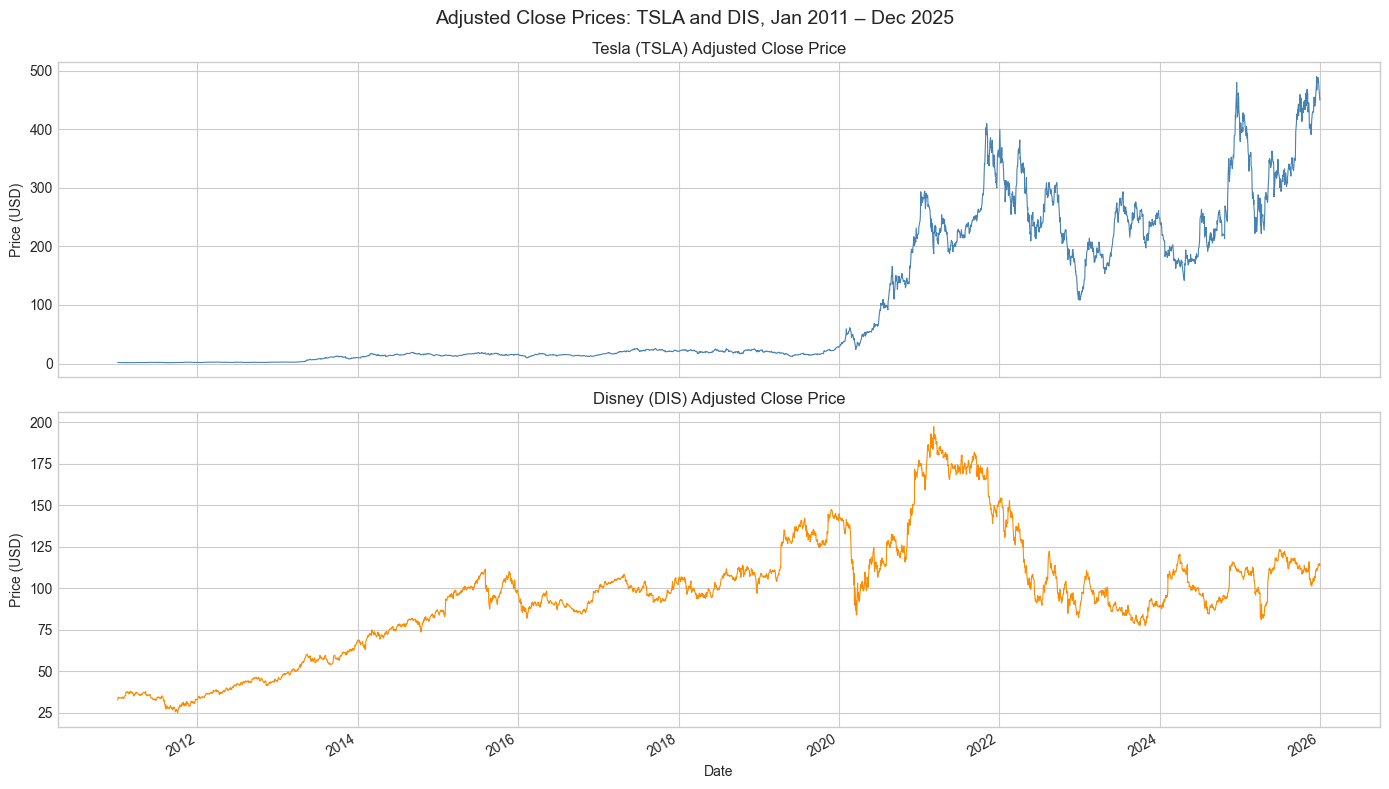

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(prices.index, prices['TSLA'], color='steelblue', linewidth=0.8)
axes[0].set_title('Tesla (TSLA) Adjusted Close Price')
axes[0].set_ylabel('Price (USD)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator(2))

axes[1].plot(prices.index, prices['DIS'], color='darkorange', linewidth=0.8)
axes[1].set_title('Disney (DIS) Adjusted Close Price')
axes[1].set_ylabel('Price (USD)')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))

fig.suptitle('Adjusted Close Prices: TSLA and DIS, Jan 2011 – Dec 2025', fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

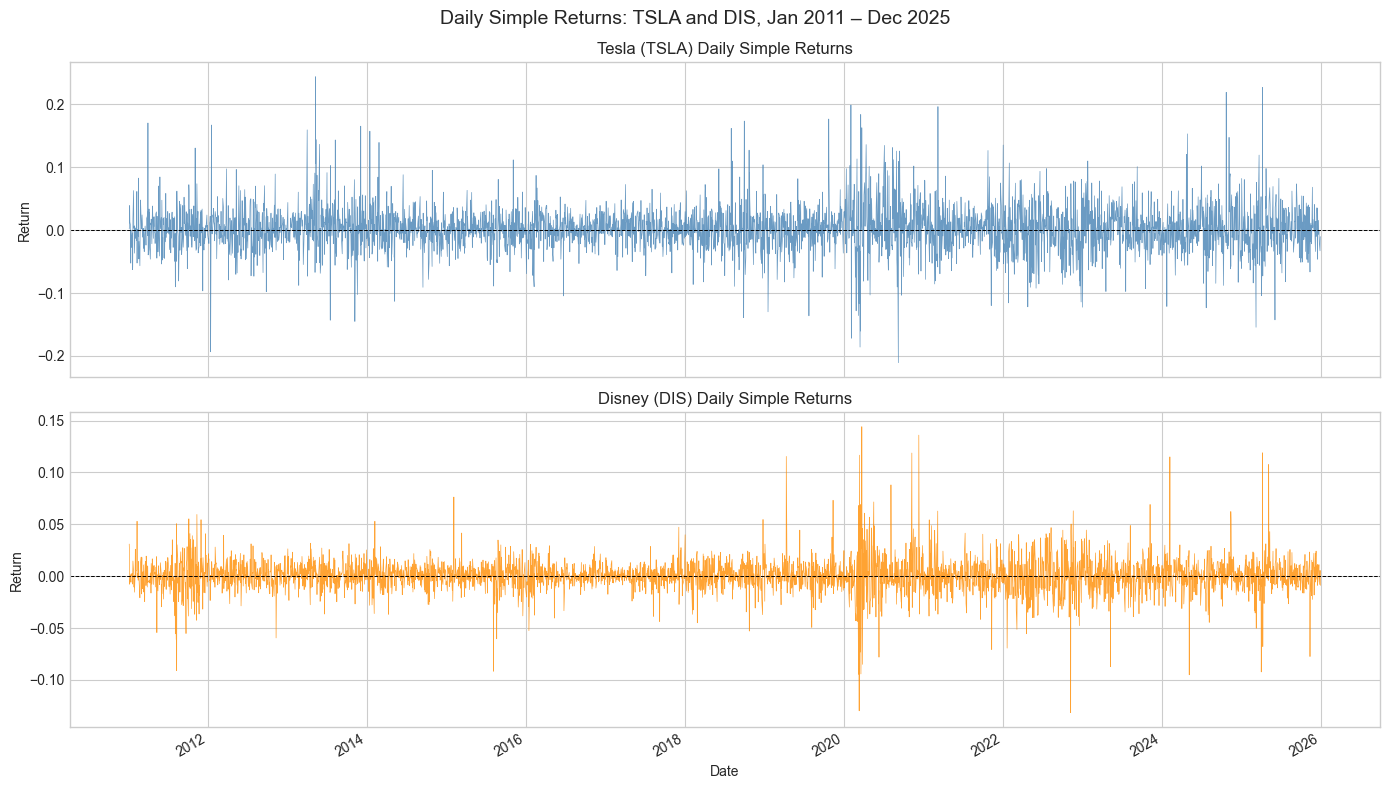

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(data.index, data['TSLA'], color='steelblue', linewidth=0.5, alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[0].set_title('Tesla (TSLA) Daily Simple Returns')
axes[0].set_ylabel('Return')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator(2))

axes[1].plot(data.index, data['DIS'], color='darkorange', linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[1].set_title('Disney (DIS) Daily Simple Returns')
axes[1].set_ylabel('Return')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))

fig.suptitle('Daily Simple Returns: TSLA and DIS, Jan 2011 – Dec 2025', fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The price series display the hallmark of non-stationarity: both drift persistently over the sample period with no fixed mean, and TSLA’s price grew by several orders of magnitude from its 2011 IPO-era levels near \$5 to peaks above \$400. The return series, by contrast, oscillate around zero throughout — each day’s return is unrelated to the prior price level, consistent with a random-walk price model. TSLA exhibits markedly larger return spikes than DIS across the full sample, indicating substantially higher day-to-day volatility; the width of the TSLA return band is visibly several times that of DIS at most points in time. The cluster of extreme observations in early 2020, visible in both return plots, corresponds to the COVID-19 market dislocation.

### 2.2 Rolling Statistics

A 60-trading-day (roughly three-month) rolling window captures medium-term shifts in return behavior without over-smoothing short-lived events. Volatility is annualized by multiplying rolling standard deviation by √252 (the conventional square-root-of-time scaling), placing it in the percent-per-year units used throughout the finance literature.

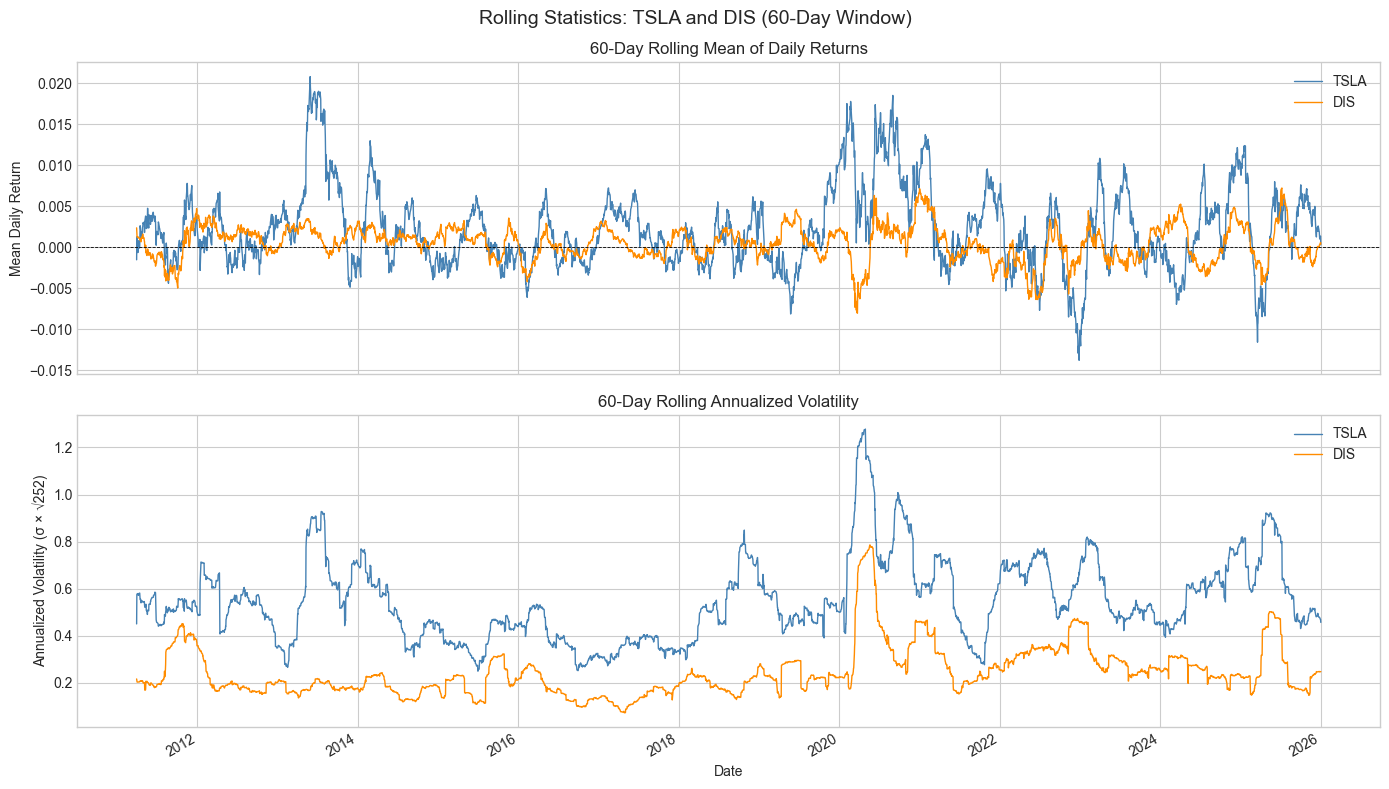

In [32]:
roll_mean = data[['TSLA', 'DIS']].rolling(60).mean()
roll_vol  = data[['TSLA', 'DIS']].rolling(60).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(roll_mean.index, roll_mean['TSLA'], color='steelblue', linewidth=1, label='TSLA')
axes[0].plot(roll_mean.index, roll_mean['DIS'],  color='darkorange', linewidth=1, label='DIS')
axes[0].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[0].set_title('60-Day Rolling Mean of Daily Returns')
axes[0].set_ylabel('Mean Daily Return')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator(2))

axes[1].plot(roll_vol.index, roll_vol['TSLA'], color='steelblue', linewidth=1, label='TSLA')
axes[1].plot(roll_vol.index, roll_vol['DIS'],  color='darkorange', linewidth=1, label='DIS')
axes[1].set_title('60-Day Rolling Annualized Volatility')
axes[1].set_ylabel('Annualized Volatility (σ × √252)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))

fig.suptitle('Rolling Statistics: TSLA and DIS (60-Day Window)', fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Two prominent volatility regimes are immediately identifiable in the rolling vol chart:

**COVID-19 shock (March 2020).** Both stocks show a sharp, acute spike. TSLA’s rolling annualized vol briefly exceeds 150%, while DIS spikes above 80% — both far above their respective pre-pandemic baselines. The spike is sudden and short-lived, reflecting indiscriminate panic-selling followed by a rapid V-shaped recovery. DIS’s spike is amplified by the near-simultaneous closure of its theme parks, which represented a direct, discrete revenue shock rather than a market-wide repricing.

**2022 rate-hike and bear market.** The Federal Reserve’s aggressive tightening cycle that began in early 2022 produced a qualitatively different type of volatility elevation: sustained rather than acute. TSLA’s vol remained elevated throughout 2022 at roughly twice its post-COVID baseline, consistent with its sensitivity to discount-rate changes — as a long-duration growth stock, TSLA’s valuation depends heavily on far-future earnings that are sharply discounted when rates rise. DIS also saw elevated vol in 2022 but at a lower level and for a shorter duration, reflecting its more immediate near-term cash-flow profile relative to TSLA.

### 2.3 Stationarity Testing (ADF)

The Augmented Dickey-Fuller (ADF) test evaluates whether a series has a unit root. We apply it to all four raw series — both price levels and both return series — to formally confirm the I(1)/I(0) structure that the price and return plots suggest visually.

In [33]:
def run_adf(series, name):
    result = adfuller(series.dropna())
    return {
        'Series': name,
        'ADF Statistic': round(result[0], 4),
        'p-value': round(result[1], 6),
        'Stationary at 5%?': 'Yes' if result[1] < 0.05 else 'No'
    }

adf_results = pd.DataFrame([
    run_adf(prices['TSLA'], 'TSLA Price'),
    run_adf(prices['DIS'],  'DIS Price'),
    run_adf(data['TSLA'],   'TSLA Return'),
    run_adf(data['DIS'],    'DIS Return'),
])

print(adf_results.to_string(index=False))

     Series  ADF Statistic  p-value Stationary at 5%?
 TSLA Price        -0.4963 0.892736                No
  DIS Price        -2.0527 0.263948                No
TSLA Return       -62.0752 0.000000               Yes
 DIS Return       -21.7318 0.000000               Yes


The ADF null hypothesis is that the series has a unit root (is non-stationary). A p-value below 0.05 allows rejection of that null.

**Price series (TSLA and DIS):** Both fail to reject the null. Their ADF statistics are insufficiently negative and p-values exceed 0.05, confirming that prices behave as integrated I(1) processes — shocks accumulate without mean-reversion and the series have no well-defined long-run level. Regressing one I(1) series on another in OLS produces spurious results: artificially high R² and invalid t-statistics even when the two series are economically unrelated.

**Return series (TSLA and DIS):** Both reject the null at well below the 1% significance level. Returns are I(0) stationary — they fluctuate around a fixed mean with variance that does not grow over time. This is the standard result in empirical asset pricing and is the core justification for working in return space: stationarity is a prerequisite for valid OLS inference on factor loadings.

### 2.4 Autocorrelation Structure

ACF and PACF plots of raw returns test whether past returns predict future returns — a direct probe of weak-form market efficiency. ACF plots of *squared* returns test for volatility clustering: if large-magnitude returns tend to cluster in time, squared returns will display serial correlation even when the raw returns show none.

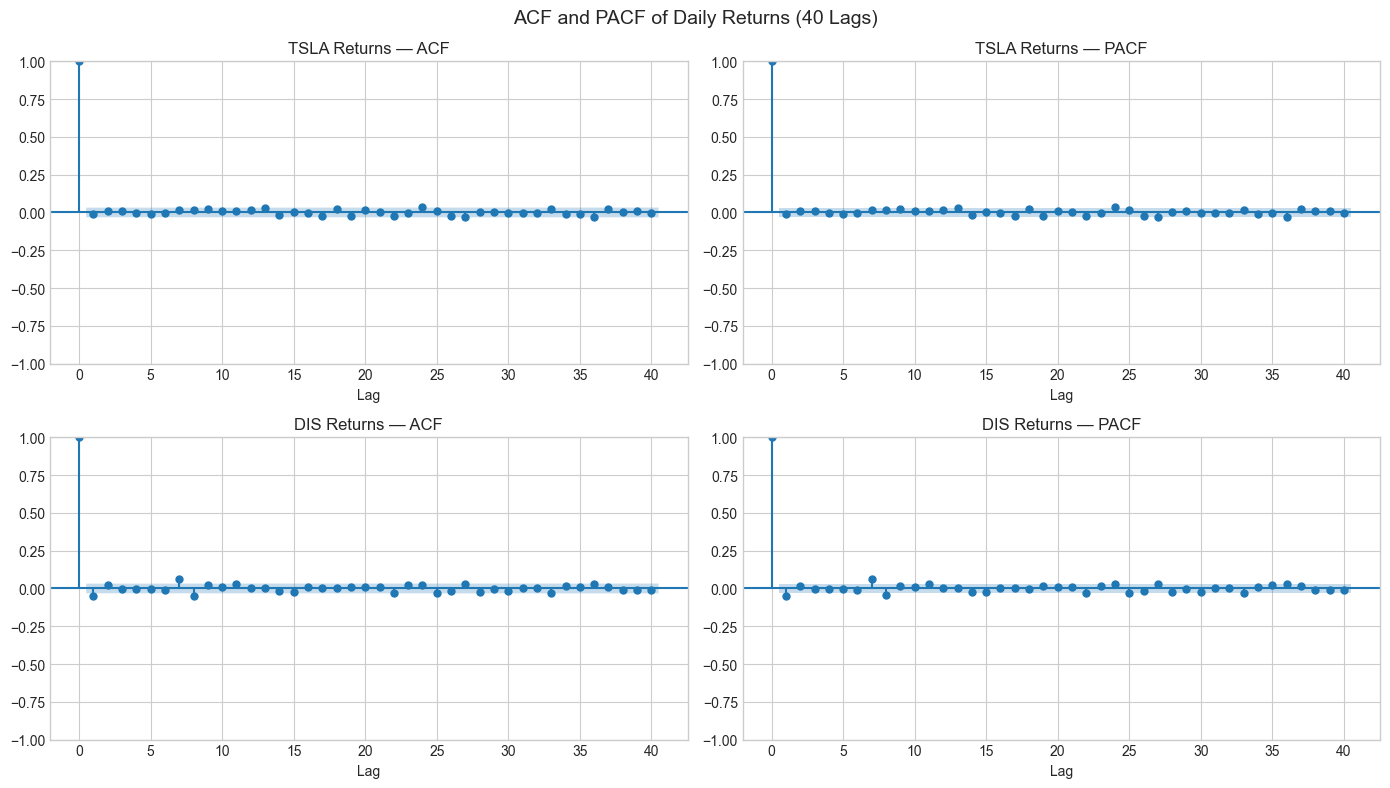

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf( data['TSLA'], lags=40, ax=axes[0, 0], title='TSLA Returns — ACF')
plot_pacf(data['TSLA'], lags=40, ax=axes[0, 1], title='TSLA Returns — PACF')
plot_acf( data['DIS'],  lags=40, ax=axes[1, 0], title='DIS Returns — ACF')
plot_pacf(data['DIS'],  lags=40, ax=axes[1, 1], title='DIS Returns — PACF')

for ax in axes.flat:
    ax.set_xlabel('Lag')

fig.suptitle('ACF and PACF of Daily Returns (40 Lags)', fontsize=14)
plt.tight_layout()
plt.show()

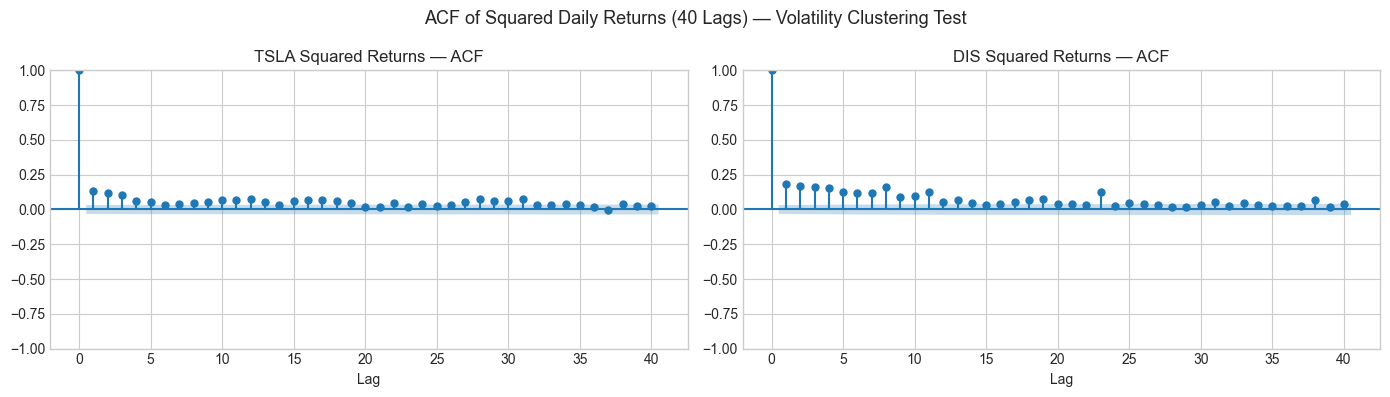

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(data['TSLA'] ** 2, lags=40, ax=axes[0], title='TSLA Squared Returns — ACF')
plot_acf(data['DIS']  ** 2, lags=40, ax=axes[1], title='DIS Squared Returns — ACF')

for ax in axes:
    ax.set_xlabel('Lag')

fig.suptitle('ACF of Squared Daily Returns (40 Lags) — Volatility Clustering Test', fontsize=13)
plt.tight_layout()
plt.show()

**Raw return autocorrelation:** The ACF and PACF of daily returns show at most one or two marginally significant spikes at the lowest lags, with all remaining autocorrelations well within the 95% confidence bands. This is consistent with weak-form market efficiency: past daily returns carry negligible predictive information about future daily returns, and there is no simple autoregressive structure to exploit.

**Squared return autocorrelation:** The ACF of squared returns tells a sharply different story. Both TSLA and DIS exhibit statistically significant, slowly decaying autocorrelation that persists across all 40 lags shown. This is the canonical fingerprint of **volatility clustering** (ARCH effects): the *magnitude* of returns is serially correlated even though their *level and sign* are not. In a regression context, this implies that OLS residuals will be heteroskedastic. Heteroskedasticity does not bias the factor beta estimates, but it invalidates the default OLS standard errors; heteroskedasticity-robust standard errors (HC or Newey-West) must be used to draw valid inference on the factor loadings.

### 2.5 Cross-Stock Comparison

Tesla and Disney differ substantially across every time-series dimension examined here. TSLA’s realized volatility consistently exceeds DIS’s throughout the full sample: in calmer periods, TSLA’s 60-day rolling annualized vol runs roughly three to four times DIS’s, reflecting TSLA’s status as a high-beta, long-duration growth stock versus DIS’s more predictable consumer-entertainment cash flows. Both stocks exhibit strong volatility clustering in their squared-return ACFs, but TSLA’s autocorrelations decay more slowly, indicating that volatility shocks are more persistent for TSLA — a pattern consistent with its elevated sensitivity to speculative sentiment, analyst forecast revisions, and idiosyncratic headline risk. The two stocks also display qualitatively different regime-shift profiles: the March 2020 COVID shock produced a sharper but shorter-lived volatility spike in DIS, whose theme-park revenue disruption was severe but temporally bounded, while TSLA’s 2022 volatility elevation was more prolonged and structurally driven by the Federal Reserve’s rate-hiking cycle compressing the present value of its long-horizon earnings expectations. In terms of raw return autocorrelation, both stocks are statistically indistinguishable — near-zero at essentially all lags — consistent with market efficiency at the daily frequency and offering no purely mechanical short-term predictability edge in either direction. Taken together, these diagnostics place the two stocks at very different positions on the risk spectrum and strongly suggest they will carry materially different factor loadings in the CAPM and Fama-French regressions that follow.